# Sparsity and Matrix Types

&nbsp;[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/themintlab/ExecutableEngineering/blob/main/chapters/linear_systems/matrix_properties/sparsity_and_types.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import executable_engineering as exe
except ImportError:
    %pip install -q executable_engineering
    import executable_engineering as exe

**Sparsity** refers to the fraction of non-zero elements in a matrix. Sparse matricies have a significant fraction of 0 elements, which can **drastically** reduce storage and computational requirements.

Storage: Typically one (conceptually) stores a matrix as a 2D array. With significant sparsity, one can instead store only non-zero entries. There is a trade-off here between access / modification and memory efficiency.

Computation: Algorithms can be designed to take advantage of the sparsity pattern for dramatic improvement in the computationl time and complexity. 

**Fill-in** is the phenomena where, during computation, zeros become non-zeros. This disrupts the sparsity pattern and the benefits that accompany it, and is hence something to be avoided.

### Matrix types

Sparsity is a geeneral description that relates to types of matricies. E.g.: Upper triangular matricies are a very useful example. It is highly desirable to preserve sparsity during decompositions / algoithms!  

|Symbol | Matrix Type | Example 2x2 | Interesting Properties |
| --- |---|---|---|
|0| Zero | $\begin{bmatrix} 0 & 0 \\ 0 & 0 \end{bmatrix}$ | A-A = 0 |
|I | Identity | $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ | A I = A |
|D|  Diagonal | $\begin{bmatrix} d_1 & 0 \\ 0 & d_2 \end{bmatrix}$ | $D^{-1}$ = $\begin{bmatrix} d_1^{-1} & 0 \\ 0 & d_2^{-1} \end{bmatrix}$ |
|U| Upper Triangular| $\begin{bmatrix} 1 & 2 \\ 0 & 4 \end{bmatrix}$ | $U^{-1}$ is another upper triangular matrix|
|L| Lower Triangular | $\begin{bmatrix} 5 & 0 \\ -1 & 2 \end{bmatrix}$ | $L^{-1}$ is another lower triangular matrix |
| P | Permutation | $\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$ | Its transpose is its inverse ($P^T = P^{-1}$) |
| S | Symmetric | $\begin{bmatrix} 1 & 3 \\ 3 & -4 \end{bmatrix}$ |  Equal to its transpose ($S = S^T$). |
| SPD | Symmetric positive definite | $\begin{bmatrix} 1 & 3 \\ 3 & 4 \end{bmatrix}$ |  $x^T [SPD] x >0$  - think of a quadratic|


## Sparsity patterns and matrix

Sparsity patterns are condensly viewed as monochrome matricies filled in according to 0 or non-zero.

Example: A sparsity pattern from a finite element problem in 2D.

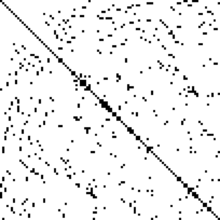

We already have examples of sparse matricies with
- diagonal
- upper and lower triangular
and have seen their importance in controlling complexity and roundoff error.

### Banded matricies

Banded matricies only have non-zero elements parallel to the diagonal. Sometimes they are described by the *bandwidth*, the number of parallel bands.



#### Tridiagonal (bandwidth 3)

[[ 2. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]


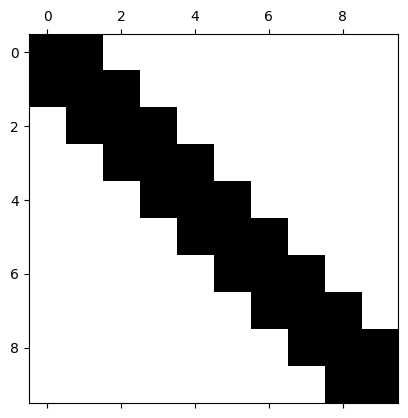

In [ ]:
# prompt: give me a tridiagonal matrix of dimension 10 and view its sparsity pattern with spy


# Create a tridiagonal matrix of dimension 10
n = 10
T = np.zeros((n, n))
np.fill_diagonal(T, 2)  # Main diagonal
np.fill_diagonal(T[1:], -1)  # Lower diagonal
np.fill_diagonal(T[:, 1:], -1)  # Upper diagonal

print(T)

# View the sparsity pattern
plt.spy(T)
plt.show()

#### Pentadiagonal (bandwidth 5)

[[ 2. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1.  2. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  2. -1. -1.  0.  0.  0.  0.]
 [ 0.  0. -1. -1.  2. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  2. -1. -1.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  2. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  2. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1.  2. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  2.]]


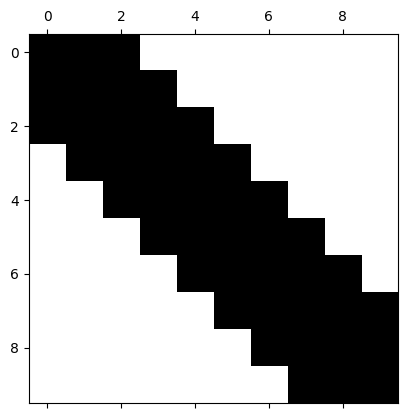

In [ ]:
# prompt: give me a pentadiagonal matrix of dimension 10 and view its sparsity pattern with spy


# Create a pentadiagonal matrix of dimension 10
n = 10
A = np.zeros((n, n))
np.fill_diagonal(A, 2)  # Main diagonal
np.fill_diagonal(A[1:], -1)  # Upper diagonal
np.fill_diagonal(A[:, 1:], -1)  # Lower diagonal
np.fill_diagonal(A[2:], -1)  # Second upper diagonal
np.fill_diagonal(A[:, 2:], -1)  # Second lower diagonal

print(A)

# View the sparsity pattern
plt.spy(A)
plt.show()

One can imagine the benefit of storing such a matrix

#### General banded matrix

[[ 2. -1.  0.  0. -1.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0. -1.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0. -1.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0. -1.  0.  0.]
 [-2.  0.  0. -1.  2. -1.  0.  0. -1.  0.]
 [ 0. -2.  0.  0. -1.  2. -1.  0.  0. -1.]
 [ 0.  0. -2.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0. -2.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0. -2.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0.  0. -2.  0.  0. -1.  2.]]


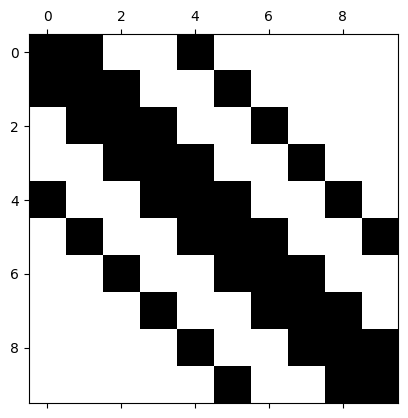

In [ ]:
# Create a pentadiagonal matrix of dimension 10
n = 10
A = np.zeros((n, n))
np.fill_diagonal(A, 2)  # Main diagonal
np.fill_diagonal(A[1:], -1)  # Upper diagonal
np.fill_diagonal(A[:, 1:], -1)  # Lower diagonal
np.fill_diagonal(A[4:], -2)  # Second upper diagonal
np.fill_diagonal(A[:, 4:], -1)  # Second lower diagonal

print(A)

# View the sparsity pattern
plt.spy(A)
plt.show()

## Block matricies

Block matricies can be partitioned:

$$ M=
\begin{bmatrix}
2 & -1 & 0 & 1 & 0 & 0 \\
-1 & 2 & -1 & 0 & 1 & 0 \\
0 & -1 & 2 & 0 & 0 & 1 \\
1 & 0 & 0 & 2 & -1 & 0 \\
0 & 1 & 0 & -1 & 2 & -1 \\
0 & 0 & 1 & 0 & -1 & 2
\end{bmatrix} = \begin{bmatrix}
A & B \\
C & D
\end{bmatrix}
$$

with

$$
A=D = \begin{bmatrix}
2 & -1 & 0  \\
-1 & 2 & -1  \\
0 & -1 & 2 \\
\end{bmatrix}
$$

and

$$
B=C = \begin{bmatrix}
1 & 0 & 0  \\
0 & 1 & 0  \\
0 & 0 & 1 \\
\end{bmatrix}
$$

The inverse can be formed:

$$
M^{-1} =
\begin{bmatrix}
A^{-1} + A^{-1}B(D - CA^{-1}B)^{-1}CA^{-1} & -A^{-1}B(D - CA^{-1}B)^{-1} \\
-(D - CA^{-1}B)^{-1}CA^{-1} & (D - CA^{-1}B)^{-1}
\end{bmatrix}
$$

This is a substantial savings since the cost of each block scales exponentially!

Sometimes we get lucky and one of the blocks is $0$ or $I$ which is a HUGE benefit!

If the blocks are each $n \times n$, $M$ is $2n \times 2n$ and takes $O((2n)^3)$ to solve. But if we partition into blocks, the inverse can be formed in 2 separate $O(n^3)$ (plus matrix multiplications).

This situation arises commonly in multiphysics applications, with two fields (e.g.: T and c). The blocks are then defined corresponding to the unknown vectors for each field.

Certaint types of physics is solved more efficiently with certain solvers. This decomposition, sometimes called *operator splitting* or *segregated solving* allows each variable (block) to be treated optimally and inverse of the full system assembled.  

In contrast, solving the matrix as a whole is called a *monolithic* solution.

### Block diagonal

Taking $B=C=0$ in the above we can see the inverse of a *block diagonal* matrix is simply the diagonal assembly of the inverse of its blocks:

$$
\begin{bmatrix}
A & 0 \\
0 & D
\end{bmatrix}^{-1} = \begin{bmatrix}
A^{-1} & 0 \\
0 & D^{-1}
\end{bmatrix}
$$